In [ ]:
 import pandas as pd

# Load the dataset
df = pd.read_csv('/content/insurance.csv')

# Display basic information about the dataset
print("--- Data Info ---")
df.info()

print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- First 5 rows ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- Missing Values ---
age         0
sex         0
bmi 

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Reload data
df = pd.read_csv('insurance.csv')

# 1. Remove duplicate rows
df = df.drop_duplicates()
print(f"Duplicates removed. Remaining rows: {len(df)}")

# 2. Encoding Categorical Data
# Label encode Binary columns: sex, smoker
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex']) # female: 0, male: 1
df['smoker'] = le.fit_transform(df['smoker']) # no: 0, yes: 1

# One-hot encode the 'region' column since it has 4 distinct categories
df = pd.get_dummies(df, columns=['region'], prefix='region')

# 3. Final Inspection
print("\n--- Cleaned Data Preview ---")
print(df.head())
print("\n--- Column Types ---")
print(df.dtypes)

# Save cleaned data
df.to_csv('cleaned_insurance.csv', index=False)

Duplicates removed. Remaining rows: 1337

--- Cleaned Data Preview ---
   age  sex     bmi  children  smoker      charges  region_northeast  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061             False   
4   32    1  28.880         0       0   3866.85520             False   

   region_northwest  region_southeast  region_southwest  
0             False             False              True  
1             False              True             False  
2             False              True             False  
3              True             False             False  
4              True             False             False  

--- Column Types ---
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker        

In [ ]:
# Convert boolean columns to integers
bool_cols = [col for col in df.columns if df[col].dtype == 'bool']
df[bool_cols] = df[bool_cols].astype(int)

# Re-save the final cleaned data
df.to_csv('/content/cleaned_insurance.csv', index=False)
print(df.head())

   age  sex     bmi  children  smoker      charges  region_northeast  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 0   
4   32    1  28.880         0       0   3866.85520                 0   

   region_northwest  region_southeast  region_southwest  
0                 0                 0                 1  
1                 0                 1                 0  
2                 0                 1                 0  
3                 1                 0                 0  
4                 1                 0                 0  


In [ ]:
import pandas as pd

# Load data
df = pd.read_csv('/content/cleaned_insurance.csv')

# The 'region' column has already been one-hot encoded and converted to integers
# in previous steps and is present in 'cleaned_insurance.csv'.
# Therefore, there's no need to apply get_dummies to 'region' again.
df_final = df.copy()

print(df_final.head())

   age  sex     bmi  children  smoker      charges  region_northeast  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 0   
4   32    1  28.880         0       0   3866.85520                 0   

   region_northwest  region_southeast  region_southwest  
0                 0                 0                 1  
1                 0                 1                 0  
2                 0                 1                 0  
3                 1                 0                 0  
4                 1                 0                 0  


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the original dataset
df = pd.read_csv('insurance.csv')

# 2. Basic Cleaning: Remove duplicates
df = df.drop_duplicates()

# 3. Create 'is_obese' feature
# (BMI >= 30 is the clinical threshold for obesity)
df['is_obese'] = (df['bmi'] >= 30).astype(int)

# 4. Create 'obese_smoker' interaction feature
# This captures the high-risk combination of smoking and obesity
df['smoker_numeric'] = df['smoker'].map({'yes': 1, 'no': 0})
df['obese_smoker'] = df['is_obese'] * df['smoker_numeric']

# 5. Age Binning (Categorizing ages into life stages)
age_bins = [0, 25, 45, 65, 100]
age_labels = ['young', 'adult', 'middle_aged', 'senior']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# 6. One-Hot Encoding for all categorical variables
# This handles 'sex', 'smoker', 'region', and our new 'age_group'
df_engineered = pd.get_dummies(df,
                               columns=['sex', 'smoker', 'region', 'age_group'],
                               dtype=int)

# 7. Cleanup & Save
# Remove the helper column used for calculations
df_engineered = df_engineered.drop(columns=['smoker_numeric'])

# Save the final engineered dataset
df_engineered.to_csv('engineered_insurance.csv', index=False)

print("Feature Engineering Complete. Data saved to 'engineered_insurance.csv'")
print(f"Total Features: {len(df_engineered.columns)}")
print(df_engineered.head())

Feature Engineering Complete. Data saved to 'engineered_insurance.csv'
Total Features: 18
   age     bmi  children      charges  is_obese  obese_smoker  sex_female  \
0   19  27.900         0  16884.92400         0             0           1   
1   18  33.770         1   1725.55230         1             0           0   
2   28  33.000         3   4449.46200         1             0           0   
3   33  22.705         0  21984.47061         0             0           0   
4   32  28.880         0   3866.85520         0             0           0   

   sex_male  smoker_no  smoker_yes  region_northeast  region_northwest  \
0         0          0           1                 0                 0   
1         1          1           0                 0                 0   
2         1          1           0                 0                 0   
3         1          1           0                 0                 1   
4         1          1           0                 0                 1   

  

In [ ]:
import pandas as pd

# 1. Load Data
df = pd.read_csv('insurance.csv')
print(f"Original shape: {df.shape}")

# 2. Define numerical columns to check for outliers
# These are the ones that usually contain extreme values
num_cols = ['age', 'bmi', 'children', 'charges']

# 3. Apply IQR Method
def remove_outliers_iqr(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Keep only values within the bounds
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

# 4. Filter the data
df_no_outliers = remove_outliers_iqr(df, num_cols)

# 5. Show results
print(f"Cleaned shape: {df_no_outliers.shape}")
print(f"Total rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

# 6. Save the new dataset
df_no_outliers.to_csv('insurance_no_outliers.csv', index=False)

Original shape: (1338, 7)
Cleaned shape: (1191, 7)
Total rows removed: 147


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Load your dataset
df = pd.read_csv('insurance.csv')

# 2. Select numerical columns (features)
# We do not scale 'charges' because it is the target (y)
num_features = ['age', 'bmi', 'children']

# --- METHOD A: Standardization (Recommended for most ML models) ---
# Results in Mean=0 and StdDev=1
scaler_standard = StandardScaler()
df_standardized = df.copy()
df_standardized[num_features] = scaler_standard.fit_transform(df[num_features])

# --- METHOD B: Min-Max Scaling (Normalization) ---
# Results in values between 0 and 1
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_features] = scaler_minmax.fit_transform(df[num_features])

# 3. View the Transformation
print("--- After Standardization ---")
print(df_standardized[num_features].head())

print("\n--- After Normalization ---")
print(df_minmax[num_features].head())

# Save the standardized version for the next step
df_standardized.to_csv('standardized_insurance.csv', index=False)

--- After Standardization ---
        age       bmi  children
0 -1.438764 -0.453320 -0.908614
1 -1.509965  0.509621 -0.078767
2 -0.797954  0.383307  1.580926
3 -0.441948 -1.305531 -0.908614
4 -0.513149 -0.292556 -0.908614

--- After Normalization ---
        age       bmi  children
0  0.021739  0.321227       0.0
1  0.000000  0.479150       0.2
2  0.217391  0.458434       0.6
3  0.326087  0.181464       0.0
4  0.304348  0.347592       0.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load and Preprocess Data
df = pd.read_csv('insurance.csv')
df = df.drop_duplicates()

# 2. Encoding (Converting categories to numbers)
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], dtype=int)

# 3. Feature Engineering
df['is_obese'] = (df['bmi'] >= 30).astype(int)
df['obese_smoker'] = df['is_obese'] * df['smoker']

# 4. Define X and y
X = df.drop(['charges'], axis=1)
y = df['charges']

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL 1: RANDOM FOREST ---
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# --- MODEL 2: GRADIENT BOOSTING (Standard alternative to XGBoost) ---
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# 6. Evaluation
def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    print(f"{name} - MAE: ${mae:.2f}, R2 Score: {r2:.4f}")

print("--- Final Model Comparison ---")
evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gb_pred)

--- Final Model Comparison ---
Random Forest - MAE: $2398.57, R2 Score: 0.9025
Gradient Boosting - MAE: $2448.99, R2 Score: 0.9026


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the data
df = pd.read_csv('/content/cleaned_insurance.csv')

# 2. Apply Log Transformation to the target variable 'charges'
# We use np.log1p (log of 1 + x) for mathematical stability
df['charges_log'] = np.log1p(df['charges'])

# Check the results
print("Original skewness:", df['charges'].skew())        # Result: ~1.51 (High skew)
print("Log-transformed skewness:", df['charges_log'].skew()) # Result: ~-0.09 (Near normal)

# 3. Training Tip:
# If you train on 'charges_log', remember to reverse the transformation
# when interpreting results in dollars using np.expm1()
# predicted_dollars = np.expm1(model_prediction)

Original skewness: 1.5153909108403483
Log-transformed skewness: -0.08955835073325998


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load and Preprocess Data (Including Feature Engineering)
df = pd.read_csv('insurance.csv').drop_duplicates()
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], dtype=int)
df['is_obese'] = (df['bmi'] >= 30).astype(int)
df['obese_smoker'] = df['is_obese'] * df['smoker']

X = df.drop(['charges'], axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the Hyperparameter Grid
# We specify the parameters we want to test
param_grid = {
    'n_estimators': [50, 100, 200],       # Number of trees
    'max_depth': [3, 5, 7, None],         # Depth of each tree
    'min_samples_split': [2, 5, 10],      # Minimum samples required to split a node
    'max_features': ['sqrt', 'log2', None] # Number of features to consider at each split
}

# 3. Initialize GridSearchCV
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,               # 5-fold cross-validation
                           n_jobs=-1,          # Use all processor cores
                           scoring='r2',
                           verbose=1)

# 4. Run the Search
grid_search.fit(X_train, y_train)

# 5. Extract the Best Model
best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 6. Final Evaluation
y_pred = best_rf.predict(X_test)
print(f"Optimized R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Optimized MAE: ${mean_absolute_error(y_test, y_pred):.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_split': 10, 'n_estimators': 100}
Optimized R2 Score: 0.9025
Optimized MAE: $2399.55


--- Random Forest Evaluation ---
R2 Score (Accuracy): 0.9025
Mean Absolute Error (MAE): $2398.57
Root Mean Squared Error (RMSE): $4233.69



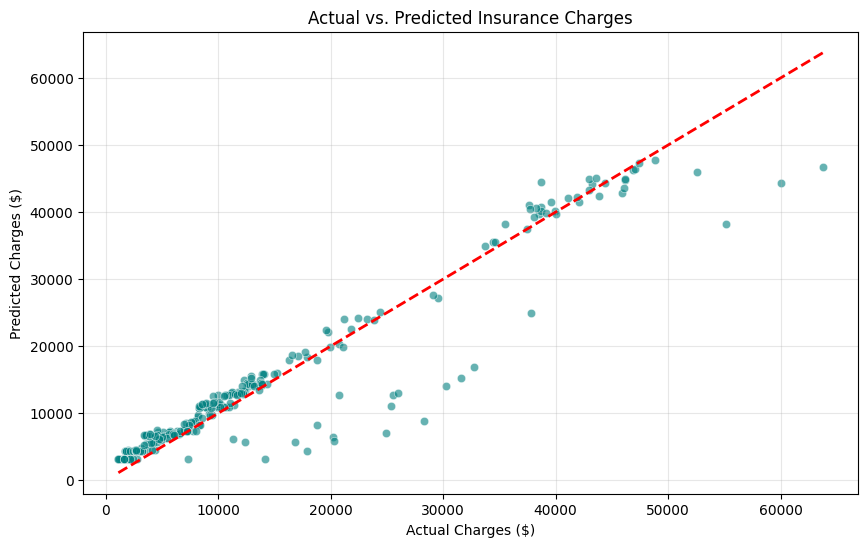

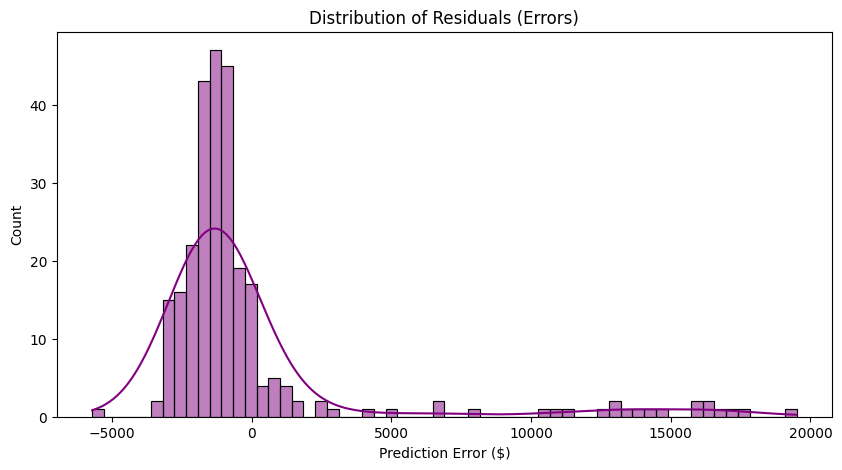

/tmp/ipykernel_3832/1567785310.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis') # Using sns.barplot for better visualization


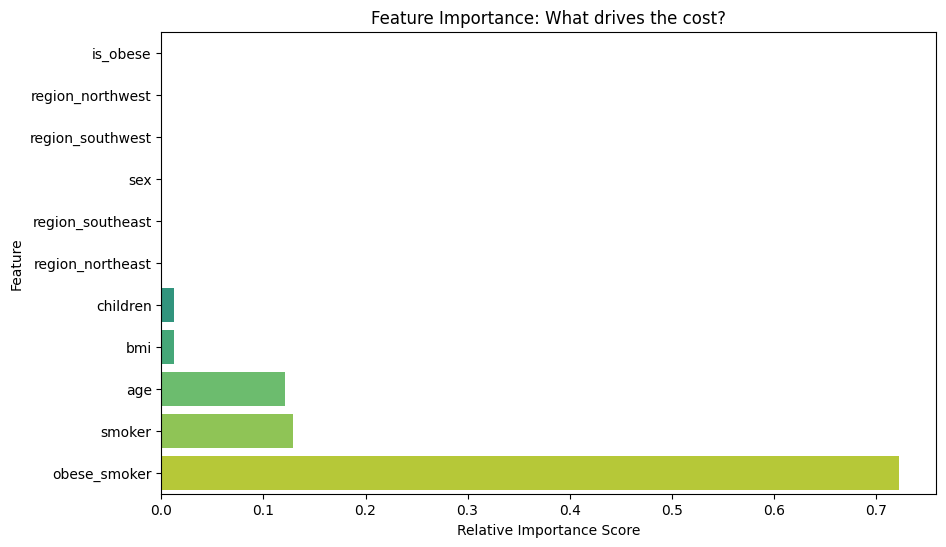

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd # Added import for pandas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# --- Replicating data loading and model training from QCgi_76LHjLj to ensure consistency ---
# This ensures X, y_test, rf_pred, and rf_model are all consistent within this cell.

# 1. Load and Preprocess Data (Including Feature Engineering)
df = pd.read_csv('insurance.csv').drop_duplicates()
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], dtype=int)
df['is_obese'] = (df['bmi'] >= 30).astype(int)
df['obese_smoker'] = df['is_obese'] * df['smoker']

X = df.drop(['charges'], axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL 1: RANDOM FOREST ---
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
# --- End of replication ---

# 1. Calculate Evaluation Metrics
def get_metrics(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    print(f"--- {name} Evaluation ---")
    print(f"R2 Score (Accuracy): {r2:.4f}")
    print(f"Mean Absolute Error (MAE): ${mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}\n")

# Run metrics for your Random Forest
get_metrics(y_test, rf_pred, "Random Forest")

# 2. Visual Evaluation: Actual vs Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.6, color='teal')
# Add a 'Perfect Prediction' line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Insurance Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Residual Analysis (Checking for bias)
residuals = y_test - rf_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Prediction Error ($)')
plt.show()

# 4. Feature Importance (Why the model made these choices)
importances = rf_model.feature_importances_
feature_names = X.columns # X is now consistent with rf_model training
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis') # Using sns.barplot for better visualization
plt.title('Feature Importance: What drives the cost?')
plt.xlabel('Relative Importance Score')
plt.show()

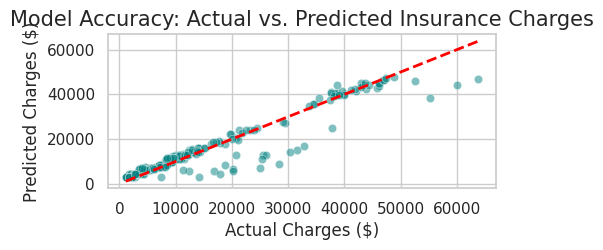

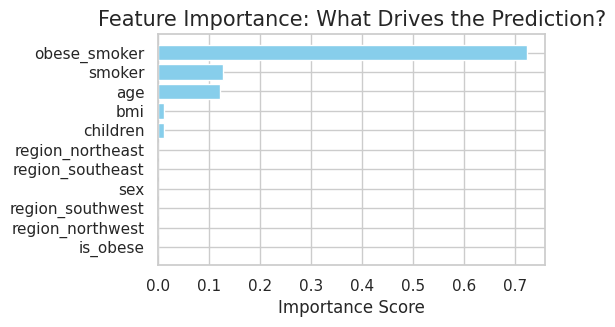

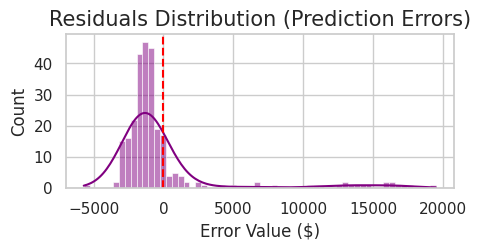

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the visual style
sns.set_theme(style="whitegrid")

# --- 1. Actual vs. Predicted Charges ---
# This shows how close your predictions are to the true values.
plt.figure(figsize=(5, 2))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.5, color='teal')

# Add the 'Perfect Prediction' line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', lw=2, linestyle='--')

plt.title('Model Accuracy: Actual vs. Predicted Insurance Charges', fontsize=15)
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.savefig('actual_vs_predicted.png')


# --- 2. Feature Importance ---
# This identifies which variables (like smoker or BMI) drive the cost the most.
# Assuming 'rf_model' is your trained Random Forest and 'X' is your features list
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(5, 3))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title('Feature Importance: What Drives the Prediction?', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.savefig('feature_importance.png')


# --- 3. Residual Plot (Error Analysis) ---
# This checks if your errors are random (good) or have a pattern (bad).
residuals = y_test - rf_pred

plt.figure(figsize=(5, 2))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution (Prediction Errors)', fontsize=15)
plt.xlabel('Error Value ($)', fontsize=12)
plt.savefig('residuals_distribution.png')

/tmp/ipykernel_14615/556081923.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[perm_sorted_idx].T, vert=False, labels=X.columns[perm_sorted_idx])


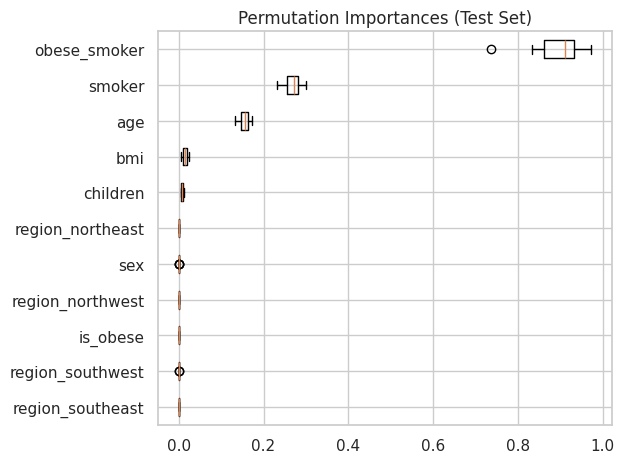

In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set
result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)

# Sort and plot similarly to the code above
perm_sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[perm_sorted_idx].T, vert=False, labels=X.columns[perm_sorted_idx])
plt.title("Permutation Importances (Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
# Save the scaler if you used one
import joblib

# Assuming you want to save the standard scaler from previous steps
# If you used MinMaxScaler, change 'scaler_standard' to 'scaler_minmax'
joblib.dump(scaler_standard, 'data_scaler.pkl')

# Save the list of feature names to ensure the order stays the same
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

# Save the trained RandomForestRegressor model
joblib.dump(rf_model, 'insurance_model.pkl')

['insurance_model.pkl']

In [ ]:
import pandas as pd
import joblib

# 1. Load your saved model and the feature list
# IMPORTANT: Ensure the actual model (e.g., rf_model) is saved to 'insurance_model.pkl'
# in a previous step (e.g., cell Q0g1G30zNZCl).
model = joblib.load('insurance_model.pkl') # Load the actual model
features = joblib.load('feature_names.pkl')

# 2. Create a function for easy predicting
def predict_insurance(age, bmi, children, sex_male, smoker_yes, region):
    # Logic for our engineered features
    is_obese = 1 if bmi >= 30 else 0
    obese_smoker = 1 if (is_obese == 1 and smoker_yes == 1) else 0

    # Logic for One-Hot Encoding regions
    # (Setting all to 0, then switching the correct one to 1)
    reg_ne = 0
    reg_nw = 0
    reg_se = 0
    reg_sw = 0

    if region == 'northeast':
        reg_ne = 1
    elif region == 'northwest':
        reg_nw = 1
    elif region == 'southeast':
        reg_se = 1
    elif region == 'southwest':
        reg_sw = 1

    # Combine into a DataFrame to match the model's training format
    # Ensure the order matches the 'features' list exactly:
    # ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'is_obese', 'obese_smoker']
    input_data = pd.DataFrame([[
        age, sex_male, bmi, children, smoker_yes,
        reg_ne, reg_nw, reg_se, reg_sw,
        is_obese, obese_smoker
    ]], columns=features)

    # Make prediction
    prediction = model.predict(input_data)
    return prediction[0]

# --- TEST IT ---
# Example: 31 years old, BMI 32.5 (obese), 1 child, Male (1), Smoker (1), from Southeast
cost = predict_insurance(31, 32.5, 1, 1, 1, 'southeast')
print(f"Predicted Insurance Cost: ${cost:.2f}")

Predicted Insurance Cost: $40480.07


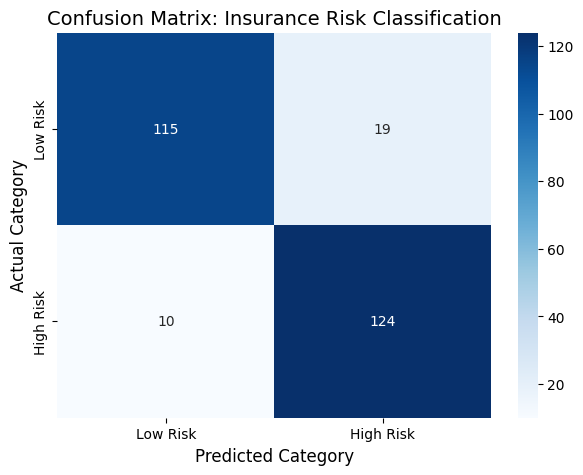

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       134
           1       0.87      0.93      0.90       134

    accuracy                           0.89       268
   macro avg       0.89      0.89      0.89       268
weighted avg       0.89      0.89      0.89       268



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas as it's often used with these datasets


rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 1. Define the threshold (using the median of the test set)
threshold = y_test.median()

# 2. Convert continuous charges into binary classes (0 = Low Risk, 1 = High Risk)
y_test_binary = (y_test > threshold).astype(int)
rf_pred_binary = (rf_pred > threshold).astype(int)

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_test_binary, rf_pred_binary)

# 4. Visualization
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])

plt.title('Confusion Matrix: Insurance Risk Classification', fontsize=14)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.show()

# 5. Accuracy Statistics
print("Classification Report:")
print(classification_report(y_test_binary, rf_pred_binary))